In [19]:
import pandas as pd

accounts = pd.read_csv("../data/raw/accounts.csv")
transactions = pd.read_csv("../data/raw/transactions.csv")
alerts = pd.read_csv("../data/raw/alerts.csv")

print("Accounts:")
print(accounts.head())

print("\nAccounts Columns:")
print(accounts.columns.tolist())

print("\nTransactions:")
print(transactions.head())

print("\nTransactions Columns:")
print(transactions.columns.tolist())

print("\nAlerts:")
print(alerts.head())

print("\nAlerts Columns:")
print(alerts.columns.tolist())

Accounts:
   ACCOUNT_ID CUSTOMER_ID  INIT_BALANCE COUNTRY ACCOUNT_TYPE  IS_FRAUD  \
0           0         C_0        184.44      US            I     False   
1           1         C_1        175.80      US            I     False   
2           2         C_2        142.06      US            I     False   
3           3         C_3        125.89      US            I     False   
4           4         C_4        151.13      US            I     False   

   TX_BEHAVIOR_ID  
0               1  
1               1  
2               1  
3               1  
4               1  

Accounts Columns:
['ACCOUNT_ID', 'CUSTOMER_ID', 'INIT_BALANCE', 'COUNTRY', 'ACCOUNT_TYPE', 'IS_FRAUD', 'TX_BEHAVIOR_ID']

Transactions:
   TX_ID  SENDER_ACCOUNT_ID  RECEIVER_ACCOUNT_ID   TX_TYPE  TX_AMOUNT  \
0      1                959                  450  TRANSFER     406.85   
1      2                245                  324  TRANSFER     469.41   
2      3                507                  980  TRANSFER      17.25

In [2]:
print("Accounts Shape:", accounts.shape)
print("Transactions Shape:", transactions.shape)
print("Alerts Shape:", alerts.shape)

Accounts Shape: (1000, 7)
Transactions Shape: (117533, 8)
Alerts Shape: (175, 9)


In [20]:
accounts.info()

print("\n")
transactions.info()

print("\n")

alerts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ACCOUNT_ID      1000 non-null   int64  
 1   CUSTOMER_ID     1000 non-null   object 
 2   INIT_BALANCE    1000 non-null   float64
 3   COUNTRY         1000 non-null   object 
 4   ACCOUNT_TYPE    1000 non-null   object 
 5   IS_FRAUD        1000 non-null   bool   
 6   TX_BEHAVIOR_ID  1000 non-null   int64  
dtypes: bool(1), float64(1), int64(2), object(3)
memory usage: 48.0+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 117533 entries, 0 to 117532
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   TX_ID                117533 non-null  int64  
 1   SENDER_ACCOUNT_ID    117533 non-null  int64  
 2   RECEIVER_ACCOUNT_ID  117533 non-null  int64  
 3   TX_TYPE              117533 non-null  object 


In [21]:
#checking if there exists missing value

print(accounts.isnull().sum())
print("\n")

print(transactions.isnull().sum())
print("\n")

print(alerts.isnull().sum())
print("\n")



ACCOUNT_ID        0
CUSTOMER_ID       0
INIT_BALANCE      0
COUNTRY           0
ACCOUNT_TYPE      0
IS_FRAUD          0
TX_BEHAVIOR_ID    0
dtype: int64


TX_ID                  0
SENDER_ACCOUNT_ID      0
RECEIVER_ACCOUNT_ID    0
TX_TYPE                0
TX_AMOUNT              0
TIMESTAMP              0
IS_FRAUD               0
ALERT_ID               0
dtype: int64


ALERT_ID               0
ALERT_TYPE             0
IS_FRAUD               0
TX_ID                  0
SENDER_ACCOUNT_ID      0
RECEIVER_ACCOUNT_ID    0
TX_TYPE                0
TX_AMOUNT              0
TIMESTAMP              0
dtype: int64




In [ ]:
# Display sample records, more easy to read

display(accounts.head())
display(transactions.head())
display(alerts.head())

,ACCOUNT_ID,CUSTOMER_ID,INIT_BALANCE,COUNTRY,ACCOUNT_TYPE,IS_FRAUD,TX_BEHAVIOR_ID
0,0,C_0,184.44,US,I,False,1
1,1,C_1,175.80,US,I,False,1
2,2,C_2,142.06,US,I,False,1
3,3,C_3,125.89,US,I,False,1
4,4,C_4,151.13,US,I,False,1


,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP,IS_FRAUD,ALERT_ID
0,1,959,450,TRANSFER,406.85,0,False,-1
1,2,245,324,TRANSFER,469.41,0,False,-1
2,3,507,980,TRANSFER,17.25,0,False,-1
3,4,507,919,TRANSFER,17.25,0,False,-1
4,5,507,962,TRANSFER,17.25,0,False,-1


,ALERT_ID,ALERT_TYPE,IS_FRAUD,TX_ID,SENDER_ACCOUNT_ID,RECEIVER_ACCOUNT_ID,TX_TYPE,TX_AMOUNT,TIMESTAMP
0,14,fan_in,True,1864,732,608,TRANSFER,2.88,4
1,14,fan_in,True,3521,813,608,TRANSFER,3.72,6
2,14,fan_in,True,4333,814,608,TRANSFER,3.66,8
3,11,fan_in,True,7876,488,889,TRANSFER,4.48,14
4,11,fan_in,True,9575,811,889,TRANSFER,3.95,16


In [22]:
# Analyze transaction types

print("Transaction types:")
print(transactions["TX_TYPE"].value_counts())

Transaction types:
TX_TYPE
TRANSFER    117533
Name: count, dtype: int64


In [24]:
# Analyze transaction amounts

print("Transaction amount statistics:")
print(transactions["TX_AMOUNT"].describe())

Transaction amount statistics:
count    1.175330e+05
mean     2.130113e+04
std      2.504431e+05
min      0.000000e+00
25%      3.451000e+01
50%      1.681300e+02
75%      4.624500e+02
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64


In [25]:
# Analyze AML / fraud alerts

print("Fraudulent transactions:", transactions["IS_FRAUD"].sum())
print("Fraudulent accounts:", accounts["IS_FRAUD"].sum())
print("Fraudulent alerts:", alerts["IS_FRAUD"].sum())

Fraudulent transactions: 175
Fraudulent accounts: 162
Fraudulent alerts: 175


可以做三個Rule

Rule 1
Large Transaction -> High-value transaction alert

Rule 2
Multiple Transactions within Short Time Window -> Velocity alert

Rule 3
Repeated Transactions
between Accounts -> Suspicious transaction pattern


/////Built and evaluated a rule-based transaction monitoring system against synthetic financial transaction data.


In [26]:
#看看 AMLSim dataset 本身把這 175 個 alerts 分成哪些類型
print("Alert types:")
print(alerts["ALERT_TYPE"].value_counts())

Alert types:
ALERT_TYPE
cycle     96
fan_in    79
Name: count, dtype: int64


In [27]:
# Check suspicious transactions by amount

fraud_transactions = transactions[transactions["IS_FRAUD"] == 1]

print(fraud_transactions["TX_AMOUNT"].describe())



count    175.000000
mean       9.877600
std        6.022304
min        2.570000
25%        3.945000
50%       10.970000
75%       15.710000
max       19.960000
Name: TX_AMOUNT, dtype: float64


In [30]:
# 分析normal transaction 和 fraudulent transaction之間tx_amount有沒有明顯差異

# Compare normal and suspicious transaction amounts

print("Normal transactions:")
print(transactions[transactions["IS_FRAUD"] == 0]["TX_AMOUNT"].describe())

print("\nSuspicious transactions:")
print(transactions[transactions["IS_FRAUD"] == 1]["TX_AMOUNT"].describe())

Normal transactions:
count    1.173580e+05
mean     2.133288e+04
std      2.506284e+05
min      0.000000e+00
25%      3.511000e+01
50%      1.681300e+02
75%      4.624500e+02
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64

Suspicious transactions:
count    175.000000
mean       9.877600
std        6.022304
min        2.570000
25%        3.945000
50%       10.970000
75%       15.710000
max       19.960000
Name: TX_AMOUNT, dtype: float64


In [32]:
#transaction frequency
# Count transactions by sender account

sender_tx_count = (
    transactions
    .groupby("SENDER_ACCOUNT_ID")
    .size()
    .sort_values(ascending=False)
)

print(sender_tx_count.head(10))

SENDER_ACCOUNT_ID
978    761
979    740
976    720
977    701
974    701
972    682
971    681
975    680
970    660
973    660
dtype: int64


Conducted exploratory data analysis (EDA) on synthetic financial transaction data to understand transaction characteristics before designing a rule-based AML monitoring workflow.


Dataset
↓

EDA
↓

Find Pattern
↓

Design Rules
↓

AML Monitoring

In [33]:
##EDA


print(accounts["COUNTRY"].value_counts())
print("\n")

print(accounts["AC" \
"COUNT_TYPE"].value_counts())

print("\n")

print(accounts["INIT_BALANCE"].describe())

print("\n")

print(transactions["TX_AMOUNT"].describe())




COUNTRY
US    1000
Name: count, dtype: int64


ACCOUNT_TYPE
I    1000
Name: count, dtype: int64


count    1000.000000
mean      279.306570
std       137.624779
min       100.020000
25%       163.280000
50%       249.160000
75%       375.452500
max       597.740000
Name: INIT_BALANCE, dtype: float64


count    1.175330e+05
mean     2.130113e+04
std      2.504431e+05
min      0.000000e+00
25%      3.451000e+01
50%      1.681300e+02
75%      4.624500e+02
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64


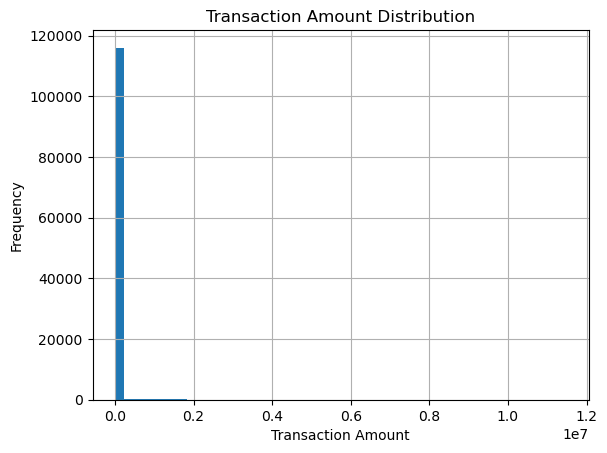

In [34]:
import matplotlib.pyplot as plt

transactions["TX_AMOUNT"].hist(bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

highly right-skewed分布極度偏態

大部分交易金額都很小，只有少數很大，所以看起來像只有一條直線

下面驗證是不是真的是這樣的情形

In [35]:
transactions["TX_AMOUNT"].describe(percentiles=[0.5,0.9,0.95,0.99,0.999])

count    1.175330e+05
mean     2.130113e+04
std      2.504431e+05
min      0.000000e+00
50%      1.681300e+02
90%      5.545800e+02
95%      5.868400e+02
99%      4.567033e+05
99.9%    4.007877e+06
max      1.147575e+07
Name: TX_AMOUNT, dtype: float64

看起來真的是因為這樣導致圖看起來像一條線
現在嘗試畫出比較可以觀察的圖

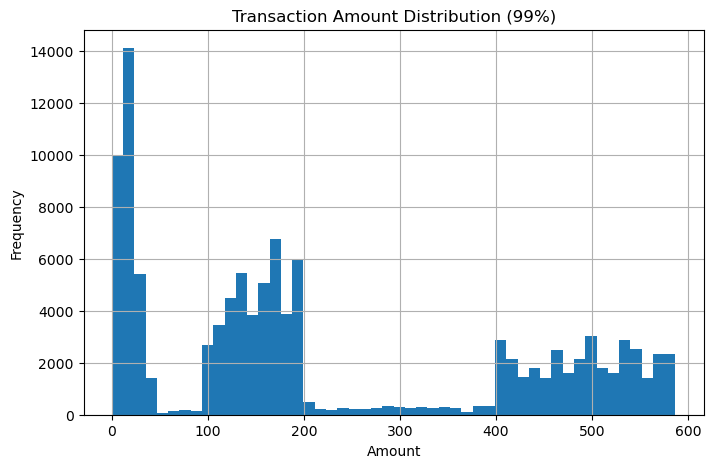

In [39]:
#限制X軸，忽略最大的1%，金融分析很常做
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

transactions["TX_AMOUNT"].hist(
    bins=50,
    range=(0, transactions["TX_AMOUNT"].quantile(0.95))
)

plt.title("Transaction Amount Distribution (99%)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

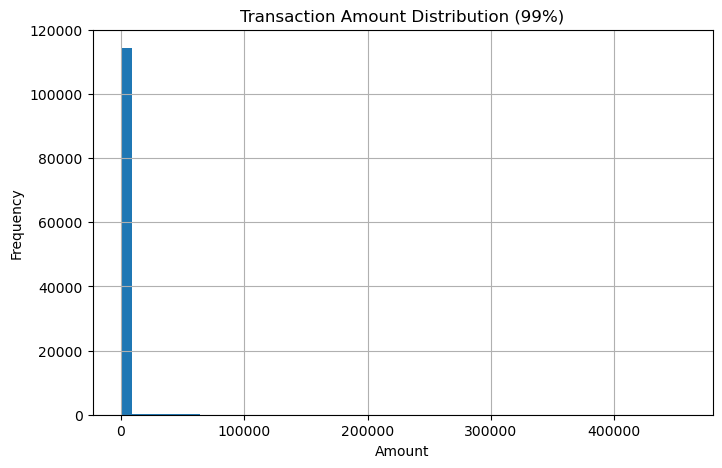

In [41]:
#對比95%和99%的圖，可見少數大額交易讓分布圖看起來非常極端
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

transactions["TX_AMOUNT"].hist(
    bins=50,
    range=(0, transactions["TX_AMOUNT"].quantile(0.99))
)

plt.title("Transaction Amount Distribution (99%)")
plt.xlabel("Amount")
plt.ylabel("Frequency")

plt.show()

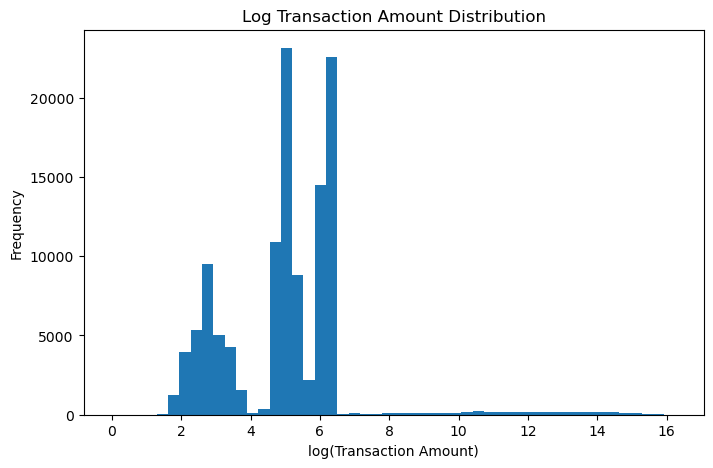

In [37]:
#log scale方法，更為專業
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    np.log1p(transactions["TX_AMOUNT"]),
    bins=50
)

plt.title("Log Transaction Amount Distribution")
plt.xlabel("log(Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

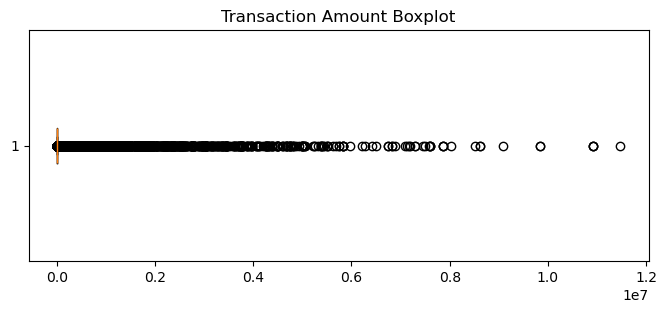

In [38]:
#box plot
plt.figure(figsize=(8,3))

plt.boxplot(transactions["TX_AMOUNT"], vert=False)

plt.title("Transaction Amount Boxplot")

plt.show()


交易金額存在大量極端值
Outlier ≠ Suspicious Transaction